In [124]:
# 1. 导入库
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']

In [125]:
# 2. 导入数据
df = pd.read_csv('data/house_sales.csv')

In [126]:
# 3. 数据概览
print('总记录数：',len(df))
print('字段数量：',len(df.columns))
df.head()
df.info()

总记录数： 106118
字段数量： 12
<class 'pandas.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   city        106118 non-null  str  
 1   address     104452 non-null  str  
 2   area        105324 non-null  str  
 3   floor       104024 non-null  str  
 4   name        105564 non-null  str  
 5   price       105564 non-null  str  
 6   province    106118 non-null  str  
 7   rooms       104036 non-null  str  
 8   toward      105240 non-null  str  
 9   unit        105564 non-null  str  
 10  year        57736 non-null   str  
 11  origin_url  105564 non-null  str  
dtypes: str(12)
memory usage: 9.7 MB


In [127]:
# 4. 数据清洗
# 删除无用的数据列
df.drop(columns='origin_url',inplace=True)

In [128]:
# 检查是否有缺失值
df.isna().sum()
# 删除缺失值
df.dropna(inplace=True)
df.isna().sum()

city        0
address     0
area        0
floor       0
name        0
price       0
province    0
rooms       0
toward      0
unit        0
year        0
dtype: int64

In [129]:
# 检查是否有重复值
df.duplicated().sum()
# 删除重复值
df.drop_duplicates(inplace=True)

In [130]:
print(len(df))

28104


In [131]:
# 面积的数据类型转换
if df['area'].dtype == 'str':
    df['area'] = df['area'].str.replace('㎡','').astype(float)
# 售价的数据类型转换
if df['price'].dtype == 'str':  # 说明还是字符串类型
    df['price'] = df['price'].str.replace('万', '').astype(float)
# 单价的数据类型转换
if df['unit'].dtype == 'str':  # 说明还是字符串类型
    df['unit'] = df['unit'].str.replace('元/㎡', '').astype(float)
# 年份的数据类型转换
if df['year'].dtype == 'str':  # 说明还是字符串类型
    df['year'] = df['year'].str.replace('年建', '').astype(int)
# 朝向的数据类型转换
df['toward'] = df['toward'].astype('category')
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012


In [132]:
print(len(df))

28104


In [133]:
# 异常值的处理
# 房屋面积的异常处理
df = df[(df["area"]<600) & (df["area"]>20)]
print(len(df))

28079


In [134]:
# 房屋售价的异常处理 IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
low_price = Q1 - 1.5*IQR
high_price = Q3 + 1.5*IQR
df = df[(df['price']>low_price) & (df['price']<high_price)]
print(len(df))

26135


In [136]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012


In [ ]:
# 5. 数据特征构造
# 地区district
df['district'] = df['address'].str.split('-').str[0]
# 楼层的类型floor_type
df['floor_type'] = df['floor'].str.split('（').str[0].astype('category')
# 是否是直辖市is_zxs
def fun1(str):
    if str in ['北京','上海','重庆','天津']:
        return True
    else:
        return False
df['is_zxs'] = df['city'].apply(fun1)
# 卧室的数量bedrooms
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)
# 客厅的数量livingrooms
# df['livingrooms'] = df['rooms'].str.split('室').str[1].str.split('厅').str[0].astype(int)
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)
# 楼龄building_age
from datetime import datetime
current_year = datetime.now().year
df['building_age'] = current_year - df['year']
# 价格的分段price_label
df['price_label'] = pd.cut(df['price'],bins=4,labels=['低价','中价','高价','豪华'])

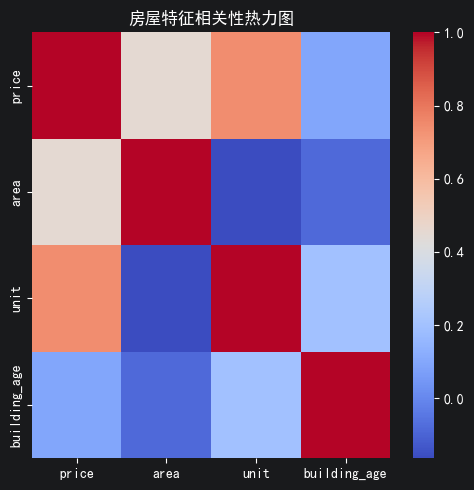

In [178]:
# 6. 问题分析及可视化
'''
问题编号: A1
问题: 哪些变量最影响房价? 面积、楼层、房间数哪个影响更大?
分析主题: 特征相关性
分析目标: 了解房屋各特征对房价的线性影响
分组字段: 无
指标/方法: 皮尔逊相关系数
'''

# 选择数值型特征
a = df[['price','area','unit','building_age']].corr()
# 对房价影响最大的几个因素的排序
a['price'].sort_values(ascending=False)[1:]
# 相关性的热力图
plt.figure(figsize=(5,5))
sns.heatmap(a,cmap='coolwarm')
plt.title('房屋特征相关性热力图')
plt.tight_layout()
plt.show()

In [179]:
'''
问题编号: A2
问题: 全国房价总体分布是怎样的? 是否存在极端值?
分析主题: 描述性统计
分析目标: 概览数值型字段的分布特征
分组字段: 无
指标/方法: 平均数/中位数/四分位数/标准差
'''
df.describe()

,area,price,unit,year,bedrooms,livingrooms,building_age
count,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000
mean,103.755810,117.208370,11610.131012,2013.072240,2.714444,1.848556,12.927760
std,33.995994,60.967675,5824.245273,6.019342,0.800768,0.407353,6.019342
min,21.000000,9.000000,1000.000000,1976.000000,0.000000,0.000000,3.000000
25%,85.005000,72.000000,7587.000000,2011.000000,2.000000,2.000000,9.000000
50%,100.000000,103.000000,10312.000000,2015.000000,3.000000,2.000000,11.000000
75%,123.000000,150.000000,14184.000000,2017.000000,3.000000,2.000000,15.000000
max,470.000000,306.000000,85288.000000,2023.000000,9.000000,12.000000,50.000000


(array([ 991., 4810., 6499., 4613., 3362., 2226., 1333., 1055.,  691.,
         555.]),
 array([  9. ,  38.7,  68.4,  98.1, 127.8, 157.5, 187.2, 216.9, 246.6,
        276.3, 306. ]),
 <BarContainer object of 10 artists>)

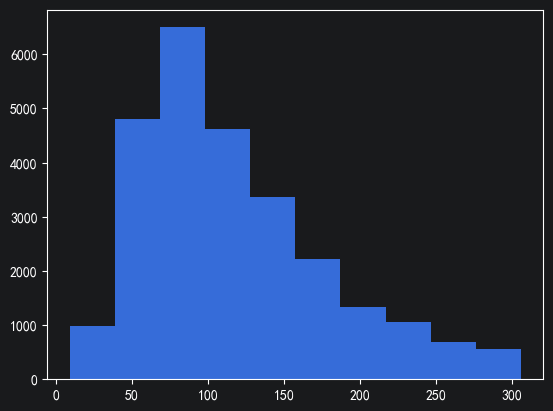

In [180]:
# 房价分布的直方图
plt.subplot()
plt.hist(df['price'],bins=10)

<Axes: xlabel='price', ylabel='Count'>

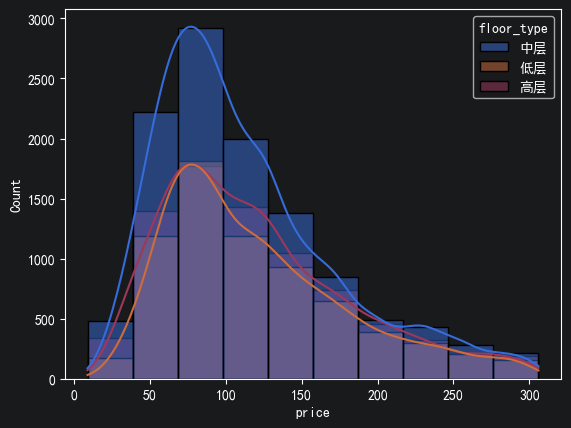

In [185]:
sns.histplot(data=df,x='price',bins=10,hue='floor_type',kde=True)

In [186]:
'''
问题编号: A6
问题: 南北向是否真比单一朝向贵? 贵多少?
分析主题: 朝向溢价
分析目标: 评估不同朝向的价格差异
分组字段: toward
指标/方法: 方差分析/多重比较
'''
df.groupby('toward').agg({
    'price':['mean','median'],
    'unit':['median']
})

price            unit
              mean median   median
toward                            
东北向     114.555333  100.0  12198.0
东南向     115.542608  105.0  10864.0
东向      110.158568   95.0  11421.0
东西向      98.935099   82.0   9000.0
北向       92.527907   75.5  11698.0
南北向     119.472147  104.5  10000.0
南向      114.555016  103.0  10759.0
西北向     119.107594  105.0  12290.0
西南向     139.711811  138.4  13333.0
西向      102.662298   86.0  12528.0

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

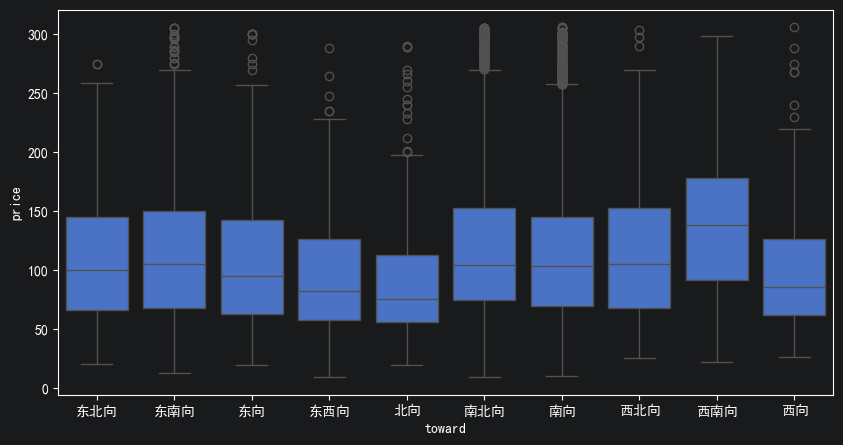

In [188]:
# 数据可视化
plt.figure(figsize=(10,5))
sns.boxplot(x='toward',y='price',data=df)
plt.tight_layout

In [166]:
df.info()

<class 'pandas.DataFrame'>
Index: 26135 entries, 0 to 106088
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   city         26135 non-null  str     
 1   address      26135 non-null  str     
 2   area         26135 non-null  float64 
 3   floor        26135 non-null  str     
 4   name         26135 non-null  str     
 5   price        26135 non-null  float64 
 6   province     26135 non-null  str     
 7   rooms        26135 non-null  str     
 8   toward       26135 non-null  category
 9   unit         26135 non-null  float64 
 10  year         26135 non-null  int64   
 11  district     26135 non-null  object  
 12  floor_type   26135 non-null  category
 13  is_zxs       26135 non-null  bool    
 14  bedrooms     26135 non-null  int64   
 15  livingrooms  26135 non-null  int64   
dtypes: bool(1), category(2), float64(3), int64(3), object(1), str(6)
memory usage: 2.9+ MB


In [170]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,is_zxs,bedrooms,livingrooms,building_age,price_label
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,龙岗,中层,False,3,2,13,中价
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,生态公园,中层,False,3,2,7,中价
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,撮镇,中层,False,2,1,9,低价
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,龙岗,高层,False,2,1,7,低价
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,新亚汽车站,中层,False,4,2,14,高价
